In [1]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed

import dynestyx as dsx
from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution


import jax
import optax
from optax import sgd, adam

# Learning in controlled dynamics: learning the control and system identification

This notebook demonstrates how to solve two problems in the context of a controlled dynamical system. The first is that of optimizing a control policy, given known dynamics. The other is system identification: given an observed system where we know the controller, identify the underlying dynamics. 

## Learning the control: optimizing a linear feedback control


We first demonstrate how to optimize a simple feedback control by computing gradients through `DiscreteControlLoopSimulator`
We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

### Defining the dynamics

Simple linear dynamics from [controller demo](controller_demo.ipynb):

$$
x_{k+1} = Ax_k + u_k + \eta_k,
$$


In [2]:
state_dim = control_dim = obs_dim = 2
A = jnp.array([[1.0, 0.05], [0.05, 1.0]])

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([0.0, 0.0]), 5.0 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=A, B=jnp.eye(control_dim), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)



### 2. Defining a controller

We implement the simple linear feedback look $u = -Kx$ and attempt to optimize $K$.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def initial_state(self): # technically optional, if absent the simulator will assume that s_0 is None
        """Stateless policy: s is always None."""
        return None

    def __call__(self, x_hat, t_now, t_next, s): # here t_now, t_next and s are unused, but they are passed in by the simulator
        return -self.K @ x_hat.mean, s # here we only use the mean of the distribution

### 3. Differentiating through the closed loop

`DiscreteControlLoopSimulator` is pure JAX under the hood and so we can compute gradients. Since this doesn't need NumPyro's tracing machinery (no conditioning, no MCMC), we call `sim.simulate(dynamics, rng_key=..., predict_times=...)` directly instead of going through `dsx.sample`/`numpyro.handlers.seed` -- this makes the PRNG key explicit, which matters once we optimize `K` over many epochs in section 4: each epoch gets a fresh key rather than reusing the same fixed noise realization, so the optimizer can't simply overfit `K` to one specific trajectory.

In [4]:
predict_times_short = jnp.arange(0.0, 5.0)

def rollout_final_state_norm(K: float, key):
    policy = LinearPolicy(K=K)
    res=  dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times_short,
        control_policy=policy,
        filter_config=KFConfig(record_filtered_states_mean=True),
    )
    return jnp.linalg.norm(res.states[0, -1]) # final state norm




K0 = jnp.eye(state_dim) * 1e-1 # initial guess for the feedback, very weak
key0 = jax.random.PRNGKey(0)
loss_value = rollout_final_state_norm(K0, key0)
grad_K = jax.grad(rollout_final_state_norm)(K0, key0)
print("Initial loss value:", loss_value)
print("Gradient of loss w.r.t K:", grad_K)

Initial loss value: 2.9383729
Gradient of loss w.r.t K: [[-7.042874  -2.4945865]
 [-3.0405126 -1.0349144]]


In [5]:
# Finite-difference check for one entry of K (K[0, 0]) which confirms the
# autodiff gradient through the whole closed loop is correct.
eps = 1e-3
K_plus = K0.at[0, 0].add(eps)
K_minus = K0.at[0, 0].add(-eps)
finite_diff = (
    rollout_final_state_norm(K_plus, key0) - rollout_final_state_norm(K_minus, key0)
) / (2 * eps)

print(f"autodiff grad_K[0, 0]:       {grad_K[0, 0]:.6f}")
print(f"finite-difference estimate: {finite_diff:.6f}")
assert jnp.allclose(grad_K[0, 0], finite_diff, atol=1e-3)
print("OK: matches within tolerance")

autodiff grad_K[0, 0]:       -7.042874
finite-difference estimate: -7.042884
OK: matches within tolerance


### 4. Optimizing the controller

Here we optimize the control matrix $K$ by unrolling forward over a short time and sampling a new initial condition at each optimization step.

In [6]:
epochs = 100
learning_rate = 1e-2
losses = []

optimizer = adam(learning_rate)
K_opt = jnp.copy(K0)
optim_state = optimizer.init(K_opt)
key = jax.random.PRNGKey(0)
for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    loss_value = rollout_final_state_norm(K_opt, subkey)
    grad_K = jax.grad(rollout_final_state_norm)(K_opt, subkey)

    updates, optim_state = optimizer.update(grad_K, optim_state)
    K_opt = optax.apply_updates(K_opt, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss_value:.4f}, K={K_opt}")
    losses.append(loss_value)

Epoch 0: Loss=4.0010, K=[[0.10999993 0.00999993]
 [0.00999993 0.10999993]]


Epoch 10: Loss=2.0838, K=[[0.1749484  0.04690327]
 [0.04341999 0.1796291 ]]


Epoch 20: Loss=0.6758, K=[[0.23478004 0.07953704]
 [0.09390181 0.25439394]]


Epoch 30: Loss=0.8867, K=[[0.30282038 0.06928785]
 [0.09812948 0.3178625 ]]


Epoch 40: Loss=1.1535, K=[[0.36505106 0.03483735]
 [0.08312446 0.36879534]]


Epoch 50: Loss=0.9188, K=[[0.40460956 0.01915101]
 [0.06484943 0.4058449 ]]


Epoch 60: Loss=0.4701, K=[[0.4391008  0.01953797]
 [0.04770527 0.42586547]]


Epoch 70: Loss=0.3120, K=[[0.46266517 0.02782553]
 [0.04412243 0.43960825]]


Epoch 80: Loss=0.4680, K=[[0.47256732 0.02857699]
 [0.03968407 0.44886035]]


Epoch 90: Loss=0.5510, K=[[0.48389488 0.03016841]
 [0.03574421 0.46921387]]


Text(0, 0.5, 'Loss (||x_T||)')

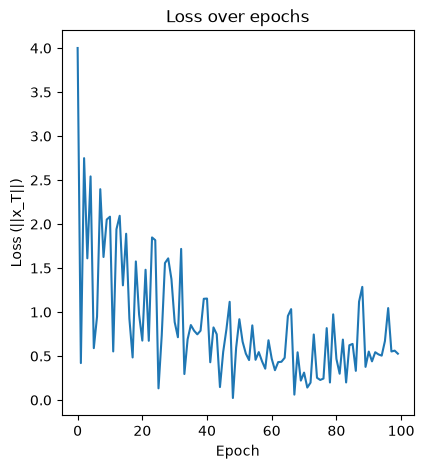

In [7]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (||x_T||)")    

We now run the loop with both the initial and optimized K to compare results. Our optimized controller drives the system to zero much more quickly compared to the initial controller we chose.

In [8]:
predict_times = jnp.arange(0.0, 30.0)

def run(K: float, key):
    policy = LinearPolicy(K=K)
    res=  dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times,
        control_policy=policy,
        filter_config=KFConfig(record_filtered_states_mean=True),
    )
    return res


trace_unopt = run(K0, key0)
trace_opt = run(K_opt, key0)

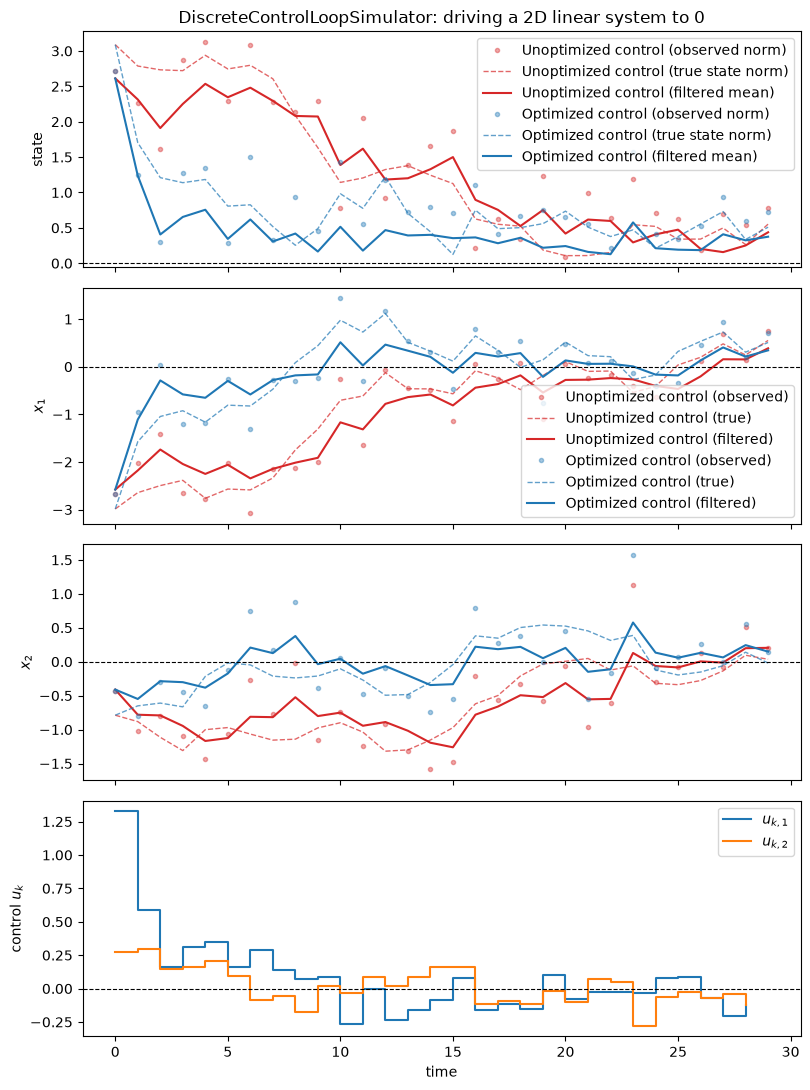

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(8, 11), sharex=True)

runs = [
    (trace_unopt, "Unoptimized control", "tab:red"),
    (trace_opt, "Optimized control", "tab:blue"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0]
    obs = result.observations[0]
    filtered_mean = result.filtered_states_mean[0]
    true_norm = jnp.linalg.norm(true_state, axis=-1)
    obs_norm = jnp.linalg.norm(obs, axis=-1)
    filtered_norm = jnp.linalg.norm(filtered_mean, axis=-1)
    axes[0].plot(t, obs_norm, ".", color=color, alpha=0.4, label=f"{label} (observed norm)")
    axes[0].plot(t, true_norm, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state norm)")
    axes[0].plot(t, filtered_norm, "-", color=color, label=f"{label} (filtered mean)")
    axes[1].plot(t, obs[:, 0], ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[1].plot(t, true_state[:, 0], "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true)")
    axes[1].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
    axes[2].plot(t, obs[:, 1], ".", color=color, alpha=0.4)
    axes[2].plot(t, true_state[:, 1], "--", color=color, alpha=0.7, linewidth=1)
    axes[2].plot(t, filtered_mean[:, 1], "-", color=color)

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 2D linear system to 0")

axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("$x_1$")
axes[1].legend()

axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("$x_2$")

t_u = trace_opt.times[0][:-1]
u_1 = trace_opt.controls[0, :, 0]
u_2 = trace_opt.controls[0, :, 1]

axes[3].step(t_u, u_1, where="post", color="tab:blue", label="$u_{k,1}$")
axes[3].step(t_u, u_2, where="post", color="tab:orange", label="$u_{k,2}$")
axes[3].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[3].legend()
axes[3].set_ylabel("control $u_k$")
axes[3].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. System identification: learning the dynamics matrix `A` through MPPI

Here we consider a dynamical system controler my an MPC type controller, see [Model Predictive Control Demo](mpc_demo.ipynb) for an introduction. Given the dynamics 

$$
\begin{aligned}
x_{k+1} &= ax_k + \pi_{\text{MMPI}}(x_k; a) + \varepsilon_k \\
y_k &= a_k + \eta_k
\end{aligned}
$$
Here we assume that the transition value $a$ is unknown, while the controller $\pi_{\text{MMPI}}$ is known and implemented by `dynestyx.control.MPPI` with loss function $\ell(x) = x^2$ (driving the system to 0).

Note that the $a$ parameter enters in 2 places: in the dynamics themselves but also in the MPPI internal planning, which unrolls the dynamics forward in time. The gradient computation therefore has to flow through both of these

Setup:
- A "true" system (`a_true`) provides one fixed reference trajectory, computed once.
- A "learned" system starts from a deliberately wrong `a_init` and is optimized to minimize the
  squared residual against that fixed reference.
- Both systems use an *identical* `MPPI` (same loss, horizon, samples, seed).
- We use `KFConfig()`: the dynamics are genuinely linear-Gaussian on both sides, so the Kalman
  filter is exact here.

In [55]:
from dynestyx.control import MPPI

state_dim_sysid = control_dim_sysid = obs_dim_sysid = 1
sysid_noise_cov = 1e-3 * jnp.eye(state_dim_sysid)
B_sysid = jnp.eye(control_dim_sysid)
A_true_val = jnp.array([[1.05]]) 
A_init = jnp.array([[0.1]])  # deliberately wrong initial guess


def make_sysid_dynamics(A):
    return DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.array([3.0]), sysid_noise_cov),
        state_evolution=LinearGaussianStateEvolution(A=A, B=B_sysid, cov=sysid_noise_cov),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(obs_dim_sysid, state_dim_sysid), R=sysid_noise_cov
        ),
        control_dim=control_dim_sysid,
    )


def sysid_loss(x_seq, u_seq):
    return jnp.sum(x_seq**2) + 0.01 * jnp.sum(u_seq**2)


def make_sysid_mppi(dynamics):
    return MPPI(dynamics=dynamics, loss_fn=sysid_loss, horizon=8, n_samples=32, seed=0)


predict_times_sysid = jnp.arange(0.0, 5.0)

In [56]:
# Reference trajectory from the true system, computed once.
dynamics_true = make_sysid_dynamics(A_true_val)
mppi_true = make_sysid_mppi(dynamics_true)
result_true = dsx.simulate(
    dynamics_true,
    rng_key=jax.random.PRNGKey(1),
    predict_times=predict_times_sysid,
    control_policy=mppi_true,
    filter_config=KFConfig(),
)
x_true = result_true.states[0]

In [57]:
# Rebuilds dynamics/MPPI fresh from the differentiable `A` argument each call
# -- same pattern as rollout_final_state_norm(K, key) above.
def trajectory_residual(A, key):
    dynamics_learned = make_sysid_dynamics(A)
    mppi_learned = make_sysid_mppi(dynamics_learned)
    result_learned = dsx.simulate(
        dynamics_learned,
        rng_key=key,
        predict_times=predict_times_sysid,
        control_policy=mppi_learned,
        filter_config=KFConfig(),
    )
    return jnp.sum((result_learned.states[0] - x_true) ** 2)

Finite-difference check, before running the full optimization. The gradient path must go through the dynamics and MPPI's planning, so we verify it once.

In [58]:
key0 = jax.random.PRNGKey(0)
loss0 = trajectory_residual(A_init, key0)
grad_A = jax.grad(trajectory_residual)(A_init, key0)

eps = 1e-3
finite_diff = (
    trajectory_residual(A_init.at[0, 0].add(eps), key0)
    - trajectory_residual(A_init.at[0, 0].add(-eps), key0)
) / (2 * eps)

print("Initial loss value:", loss0)
print(f"autodiff grad_A[0, 0]:       {grad_A[0, 0]:.6f}")
print(f"finite-difference estimate: {finite_diff:.6f}")
assert jnp.allclose(grad_A[0, 0], finite_diff, atol=1e-2)
print("OK: matches within tolerance")

Initial loss value: 3.9476647
autodiff grad_A[0, 0]:       -1.645013
finite-difference estimate: -1.644969
OK: matches within tolerance


Now optimize `A`, resampling the environment noise (a fresh key) every epoch so the optimizer
can't overfit to one particular noise realization -- same practice as Section 4.

In [59]:
sysid_epochs = 50
sysid_learning_rate = 5e-2
sysid_losses = []

sysid_optimizer = adam(sysid_learning_rate)
A_opt = jnp.copy(A_init)
sysid_optim_state = sysid_optimizer.init(A_opt)
key = jax.random.PRNGKey(0)
for epoch in range(sysid_epochs):
    key, subkey = jax.random.split(key)
    loss_value = trajectory_residual(A_opt, subkey)
    grad_A = jax.grad(trajectory_residual)(A_opt, subkey)

    updates, sysid_optim_state = sysid_optimizer.update(grad_A, sysid_optim_state)
    A_opt = optax.apply_updates(A_opt, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss_value:.4f}, A={A_opt.ravel()}")
    sysid_losses.append(loss_value)

print("True A:   ", A_true_val.ravel())
print("Learned A:", A_opt.ravel())

Epoch 0: Loss=3.9985, A=[0.14999966]
Epoch 10: Loss=1.5990, A=[0.6493242]
Epoch 20: Loss=1.4305, A=[0.8922659]
Epoch 30: Loss=1.4584, A=[0.7881495]
Epoch 40: Loss=1.3630, A=[0.837612]
True A:    [1.05]
Learned A: [0.8470579]


We do a reasonable job in recovering the true system parameter $a$. We now plot the resulting controlled dynamical system for the true, initial and optimized dynamics.

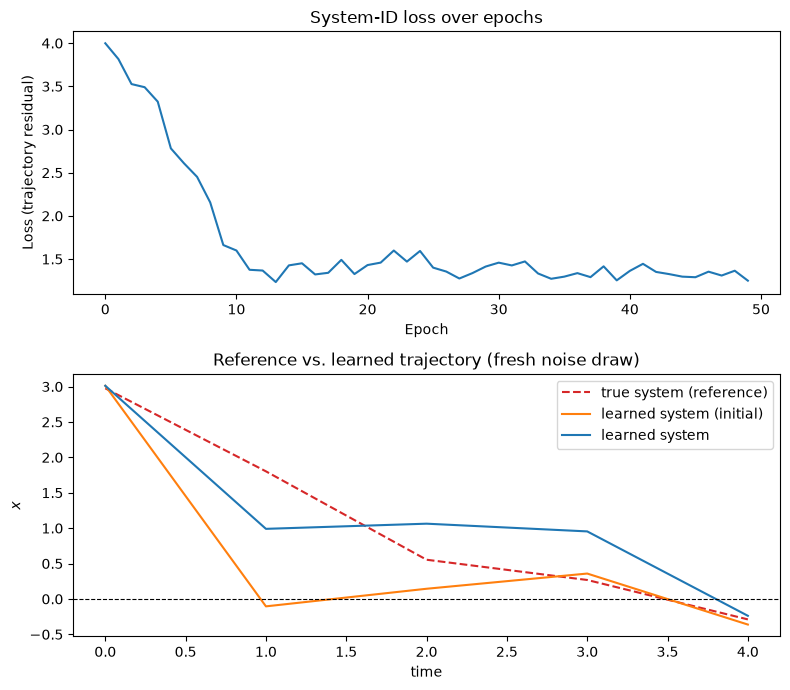

In [60]:
dynamics_learned_final = make_sysid_dynamics(A_opt)
dynamics_learned_init = make_sysid_dynamics(A_init)
result_learned_final = dsx.simulate(
    dynamics_learned_final,
    rng_key=jax.random.PRNGKey(2),
    predict_times=predict_times_sysid,
    control_policy=make_sysid_mppi(dynamics_learned_final),
    filter_config=KFConfig(),
)
result_learned_init = dsx.simulate(
    dynamics_learned_init,
    rng_key=jax.random.PRNGKey(2),
    predict_times=predict_times_sysid,
    control_policy=make_sysid_mppi(dynamics_learned_init),
    filter_config=KFConfig(),
)



fig, axes = plt.subplots(2, 1, figsize=(8, 7))

axes[0].plot(sysid_losses)
axes[0].set_title("System-ID loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (trajectory residual)")

t = predict_times_sysid
axes[1].plot(t, x_true[:, 0], "--", color="tab:red", label="true system (reference)")
axes[1].plot(t, result_learned_init.states[0, :, 0], "-", color="tab:orange", label="learned system (initial)")
axes[1].plot(t, result_learned_final.states[0, :, 0], "-", color="tab:blue", label="learned system")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("$x$")
axes[1].set_xlabel("time")
axes[1].set_title("Reference vs. learned trajectory (fresh noise draw)")
axes[1].legend()

plt.tight_layout()
plt.show()